# Gamma Speckle Noise 1024 synthetic-image example

Unit-mean gamma multiplicative speckle for integer-look simulation. This notebook starts from the same synthetic 1024 x 1024 image, applies one AGFB noise model, and displays the clean image, noisy image, and residual.


## Setup

Import the model function and notebook helpers. The autoreload lines help Jupyter pick up local source edits without restarting the kernel.


In [1]:
# Imports and local reloads.
%load_ext autoreload
%autoreload 2

import time

import torch

from agfb_noise import add_gamma_speckle
from agfb_noise.notebook import show_noise_preview, summarize_tensors, synthetic_1024_image

## Synthetic Image

Create the shared 1024 x 1024 synthetic input on CUDA when available.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 123

clean = synthetic_1024_image(device=device)
clean.shape, clean.device, clean.dtype

(torch.Size([1, 1024, 1024]), device(type='cpu'), torch.float32)

## Apply Noise

Set the model parameters and corrupt the image.


In [3]:
def apply_model() -> torch.Tensor:
    return add_gamma_speckle(clean, looks=4, seed=seed, clamp=(0.0, 1.0))


noisy = apply_model()
delta = noisy - clean

## Summary

Report compact tensor statistics for the clean, noisy, and residual images.


In [4]:
summarize_tensors(
    {
        "clean": clean,
        "noisy": noisy,
        "delta": delta,
    }
)

[{'name': 'clean',
  'min': 0.11334408074617386,
  'q01': 0.1417168229818344,
  'mean': 0.48850709199905396,
  'q50': 0.5385441184043884,
  'q99': 0.8480556011199951,
  'max': 0.9545643329620361,
  'std': 0.18355251848697662},
 {'name': 'noisy',
  'min': 0.00586278410628438,
  'q01': 0.06220564991235733,
  'mean': 0.46975791454315186,
  'q50': 0.4187755584716797,
  'q99': 1.0,
  'max': 1.0,
  'std': 0.27046993374824524},
 {'name': 'delta',
  'min': -0.8743717670440674,
  'q01': -0.48816531896591187,
  'mean': -0.018749166280031204,
  'q50': -0.032400861382484436,
  'q99': 0.46576035022735596,
  'max': 0.8516314029693604,
  'std': 0.21570803225040436}]

## Preview

The preview down-samples the 1024 image for display. The residual uses a blue-white-garnet diverging map.



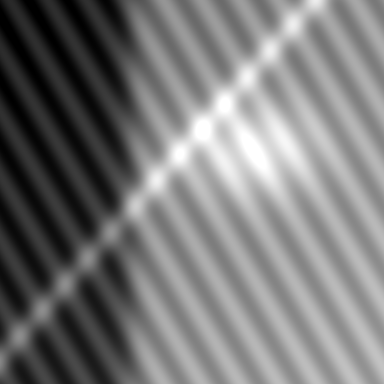
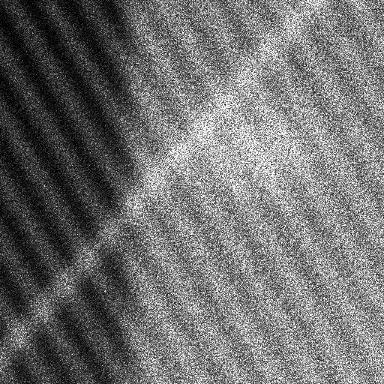
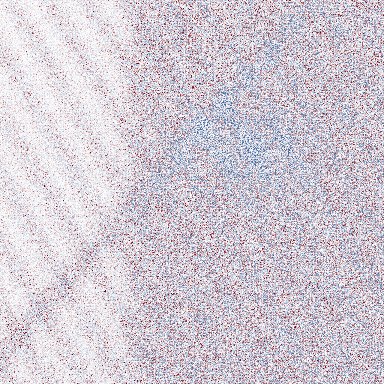


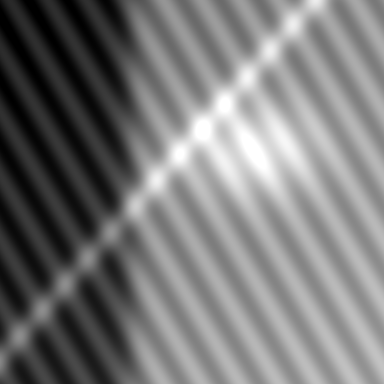
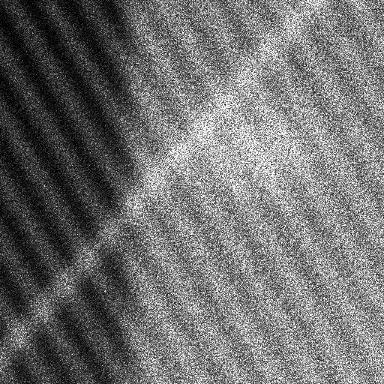
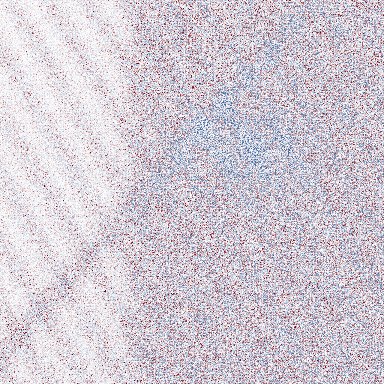

In [5]:
show_noise_preview(clean, noisy, title="Gamma Speckle Noise")

## Timing

Time one hot-path model application on the selected device.


In [6]:
if clean.is_cuda:
    torch.cuda.synchronize()
start = time.perf_counter()
_ = apply_model()
if clean.is_cuda:
    torch.cuda.synchronize()
elapsed_ms = (time.perf_counter() - start) * 1000.0
elapsed_ms

21.789124934002757